# Random forest for classification

[Master Tree Ensemble Models course](https://www.trainindata.com/p/master-tree-ensemble-models)

In this notebook, we train a random forest to predict which clients subscribe to a term deposit. We start with the default parameters, then we look at how the number of trees and the depth of the trees affect the performance, and finally we tune the hyperparameters with a random search.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split

### Load data

We use the bank marketing data that we prepared in the notebook of the folder prepare-data.

In [2]:
df = pd.read_csv("../prepare-data/bank_marketing.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,NaN,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,NaN,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,NaN,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,NaN,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,NaN,0,unknown,0


In [3]:
# the trees from Scikit-learn take numbers, so we replace the categories by integers
categorical_vars = df.select_dtypes("str").columns
df[categorical_vars] = df[categorical_vars].apply(lambda var: var.astype("category").cat.codes)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,NaN,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,NaN,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,NaN,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,NaN,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,NaN,0,3,0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns="y"),
    df["y"],
    test_size=0.3,
    stratify=df["y"],
    random_state=0,
)

X_train.shape, X_test.shape

((31647, 16), (13564, 16))

### Train the model with the default parameters

We show the hyperparameters with their default values, so that we can see the effect of changing them later on.

In [5]:
rf = RandomForestClassifier(
    # the ensemble
    n_estimators=100,     # the number of decision trees
    bootstrap=True,       # boostrap with replacement
    max_samples=None,     # number of samples to draw at each bootstrap iteration
    max_features="sqrt",  # number of features to examine at each node
    oob_score=balanced_accuracy_score,       # whether to evaluate the model

    # about the decision tree
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0,

    # additional important parameters
    random_state=0,    # for reproducibility
    n_jobs=-1,         # trees can be grown in parallel
)

rf.fit(X_train, y_train)

,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",<function bal...t 0x11b752ae0>
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes

In [6]:
# the roc in the out of sample
rf.oob_score_

0.6904992528447144

In [7]:
def evaluate(model, X_train, y_train, X_test, y_test):
    for name, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        balanced_accuracy = balanced_accuracy_score(y, model.predict(X))
        roc_auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
        print(f"{name} balanced accuracy: {balanced_accuracy:.4f}, roc-auc: {roc_auc:.4f}")

evaluate(rf, X_train, y_train, X_test, y_test)

train balanced accuracy: 1.0000, roc-auc: 1.0000
test balanced accuracy: 0.6999, roc-auc: 0.9260


The forest reaches a much better roc-auc than the single decision tree of the previous section, and we obtained it without tuning anything, which is one of the reasons why random forests are such a good first model.

The forest still shows a perfect performance in the train set, because each tree grows until its leaves are pure, and yet the performance in the test set remains high, which tells us that averaging many trees is enough to keep the overfitting under control.

### The number of trees

We train forests with a growing number of trees and we evaluate them in the test set.

In [8]:
n_estimators = [5, 10, 25, 50, 100, 200, 400, 1000]

roc_auc_values = []
for n in n_estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=0, n_jobs=-1)
    model.fit(X_train, y_train)
    roc_auc_values.append(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

pd.Series(roc_auc_values, index=n_estimators).round(4)

5       0.8586
10      0.8897
25      0.9159
50      0.9220
100     0.9260
200     0.9278
400     0.9288
1000    0.9289
dtype: float64

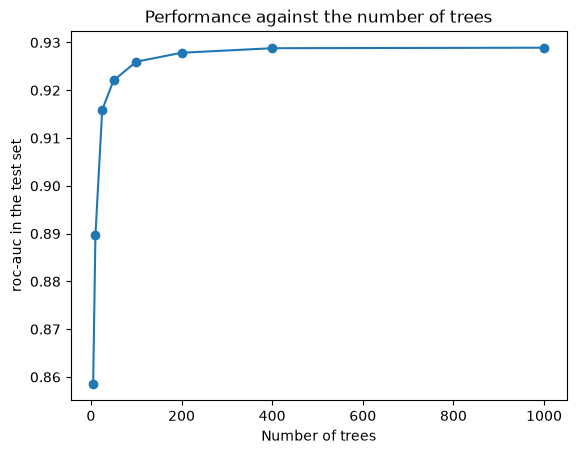

In [9]:
plt.plot(n_estimators, roc_auc_values, marker="o")
plt.xlabel("Number of trees")
plt.ylabel("roc-auc in the test set")
plt.title("Performance against the number of trees")
plt.show()

The performance improves quickly at the beginning and then it reaches a plateau, and after that point more trees cost us time without giving us anything back. Adding trees never hurts the performance, so in practice we can set a large number of trees and be safe, and the only thing we pay is the training time.

### The depth of the trees

The theory tells us that random forests work better with deep trees, because the averaging of many different trees is what controls the variance. We compare forests with shallow trees and forests with trees that grow without a limit.

In [10]:
depths = [2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 20, 24]

results = {}
for depth in depths:
    model = RandomForestClassifier(max_depth=depth, random_state=0, n_jobs=-1)
    model.fit(X_train, y_train)
    results[depth] = {
        "train": roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),
        "test": roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
    }

results = pd.DataFrame(results).T
results.round(4)

,train,test
2,0.8732,0.8724
3,0.8872,0.8843
4,0.8979,0.8932
5,0.9070,0.9022
6,0.9162,0.9075
8,0.9337,0.9146
10,0.9528,0.9203
12,0.9723,0.9238
14,0.9865,0.9251
16,0.9956,0.9271


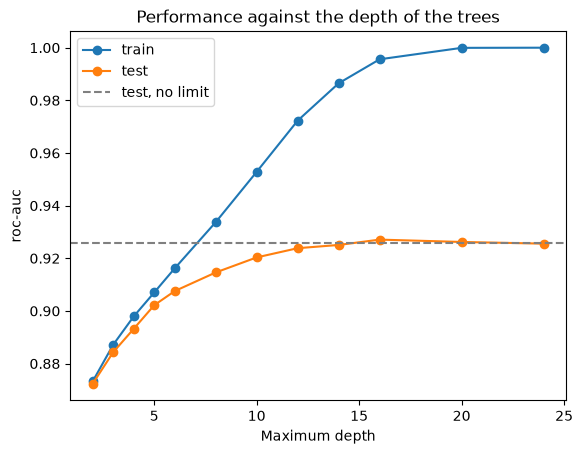

In [11]:
# the dashed line is the forest of the beginning, the one that grows without a limit
plt.plot(results.index, results["train"], marker="o", label="train")
plt.plot(results.index, results["test"], marker="o", label="test")
plt.axhline(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]), color="grey", linestyle="dashed", label="test, no limit")
plt.xlabel("Maximum depth")
plt.ylabel("roc-auc")
plt.title("Performance against the depth of the trees")
plt.legend()
plt.show()

### Search for better hyperparameters

We keep the number of trees fixed at a value that is large enough, and we sample the hyperparameters that control the growth of the trees and the randomness of the forest.

In [12]:
param_distributions = {
    "max_depth": randint(5, 30),
    "min_samples_leaf": randint(1, 50),
    "max_features": uniform(0.1, 0.6),
}

search = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1),
    param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=0,
)

search.fit(X_train, y_train)

search.best_params_

{'max_depth': 25,
 'max_features': np.float64(0.33189338867551715),
 'min_samples_leaf': 5}

In [13]:
# the standard deviation tells us how much the metric changes across the folds
results = pd.DataFrame(search.cv_results_)
results = results.sort_values("rank_test_score")

results[["mean_test_score", "std_test_score", "rank_test_score"]].head(10)

,mean_test_score,std_test_score,rank_test_score
17,0.926689,0.001843,1
0,0.925389,0.002020,2
6,0.923543,0.001573,3
8,0.923076,0.001510,4
3,0.921602,0.001363,5
10,0.921049,0.001120,6
14,0.921010,0.001001,7
5,0.920243,0.000908,8
18,0.919970,0.001049,9
9,0.919747,0.001040,10


In [14]:
best = results.iloc[0]

print(f"best cross validation roc-auc: {best['mean_test_score']:.4f} +/- {best['std_test_score']:.4f}")

best cross validation roc-auc: 0.9267 +/- 0.0018


### Evaluate the new model

We compare the performance of the tuned forest with the performance of the forest that we trained with the default hyperparameters.

In [15]:
evaluate(search.best_estimator_, X_train, y_train, X_test, y_test)

train balanced accuracy: 0.8251, roc-auc: 0.9856
test balanced accuracy: 0.7040, roc-auc: 0.9288
